# Fine-Tu

### Goal
Improve recognition of German-specific characters (ä, ö, ü, ß) while retaining English performance.

### Method
- Start from `microsoft/trocr-base-printed`
- Train on a mixture of:
  - IIIT-5K English word images (real data)
  - Synthetic German word images (rendered from a word list with augmentations)
- Evaluate with CER/WER on:
  - IIIT-5K English test split
  - Held-out synthetic German split

### Key idea
The pretrained TrOCR baseline underperforms on German due to vocabulary mismatch.
Fine-tuning adapts the decoder to German character patterns and the encoder to the synthetic style.


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import json
import random
import numpy as np
import time
import pandas as pd
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from IPython.display import display
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from jiwer import cer, wer

In [3]:
Base_dir = ".."
Dataset_dir = os.path.join(Base_dir, "Datasets")
Annot_dir = os.path.join(Dataset_dir, "Annotated_files")

iiit5k_train_ann = os.path.join(Annot_dir, "iiit5k_train_annotations.json")
iiit5k_test_ann  = os.path.join(Annot_dir, "iiit5k_test_annotations.json")
german_train_ann = os.path.join(Annot_dir, "german_train_annotations.json")
german_test_ann  = os.path.join(Annot_dir, "german_test_annotations.json")

for p in [iiit5k_train_ann, iiit5k_test_ann, german_train_ann, german_test_ann]:
    print(os.path.exists(p), p)


True ../Datasets/Annotated_files/iiit5k_train_annotations.json
True ../Datasets/Annotated_files/iiit5k_test_annotations.json
True ../Datasets/Annotated_files/german_train_annotations.json
True ../Datasets/Annotated_files/german_test_annotations.json


## Load train and test DFs

In [4]:
en_train_df = pd.read_json(iiit5k_train_ann)
en_test_df  = pd.read_json(iiit5k_test_ann)

de_train_df = pd.read_json(german_train_ann)
de_test_df  = pd.read_json(german_test_ann)

len(en_train_df), len(en_test_df), len(de_train_df), len(de_test_df)


(1156, 331, 3999, 1000)

In [39]:
## This was used to check whether lesser length data was better

"""en_train_df = en_train_df[en_train_df["label"].str.len() <= 10].reset_index(drop=True)
en_test_df  = en_test_df[en_test_df["label"].str.len() <= 10].reset_index(drop=True)

de_train_df = de_train_df[de_train_df["label"].str.len() <= 10].reset_index(drop=True)
de_test_df  = de_test_df[de_test_df["label"].str.len() <= 10].reset_index(drop=True)"""


'en_train_df = en_train_df[en_train_df["label"].str.len() <= 10].reset_index(drop=True)\nen_test_df  = en_test_df[en_test_df["label"].str.len() <= 10].reset_index(drop=True)\n\nde_train_df = de_train_df[de_train_df["label"].str.len() <= 10].reset_index(drop=True)\nde_test_df  = de_test_df[de_test_df["label"].str.len() <= 10].reset_index(drop=True)'

In [5]:
len(en_train_df), len(en_test_df), len(de_train_df), len(de_test_df)


(1156, 331, 3999, 1000)

auslobtet ../Datasets/german_synth/de_03993.png


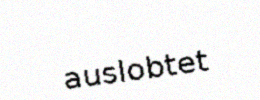

In [6]:
row = de_train_df.sample(1, random_state=0).iloc[0]
print(row["label"], row["image_path"])
display(Image.open(row["image_path"]))

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [8]:
model_name = "microsoft/trocr-base-printed"

processor = TrOCRProcessor.from_pretrained(model_name, use_fast=True)
model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)

model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size
torch.backends.cudnn.benchmark = True
#model = model.half()

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### class OCRDataset(Dataset):

    """Torch Dataset for TrOCR fine-tuning.

    Returns:
        dict with:
          - pixel_values: preprocessed image tensor (float)
          - labels: token ids for the target word (with padding tokens masked to -100)
    """


In [9]:
class OCRDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        text = row["label"]

        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze(0)
        return {"pixel_values": pixel_values, "labels": text}


In [10]:
def collate_fn(batch):
    pixel_values = torch.stack([b["pixel_values"] for b in batch])

    texts = [b["labels"] for b in batch]
    enc = processor.tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt",
    )
    labels = enc.input_ids
    labels[labels == processor.tokenizer.pad_token_id] = -100  # ignore padding in loss

    return {"pixel_values": pixel_values, "labels": labels}


In [11]:
train_df_all = pd.concat([en_train_df, de_train_df], ignore_index=True)
len(train_df_all)

5155

In [12]:
max_train_samples = 5000   # or even 5000 if needed
if len(train_df_all) > max_train_samples:
    train_df_all = train_df_all.sample(n=max_train_samples, random_state=42).reset_index(drop=True)

len(train_df_all)

5000

In [13]:
train_dataset = OCRDataset(train_df_all, processor)

batch_size = 8
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,  # Parallel data loading
    pin_memory=True  # Faster transfer to GPU
)
len(train_loader)


625

In [14]:

scaler = GradScaler("cuda")


lr = 5e-5
num_epochs = 5
optimizer = AdamW(model.parameters(), lr=lr)
scaler = GradScaler("cuda")

model.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    for step, batch in enumerate(train_loader):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with autocast("cuda"):
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
        
        # Scale loss and backward pass
        scaler.scale(loss).backward()
        
        # Unscale gradients and clip
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update weights
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        
        if (step + 1) % 50 == 0:
            avg = total_loss / (step + 1)
            print(f"Epoch {epoch+1}/{num_epochs} | Step {step+1}/{len(train_loader)} | Loss {avg:.4f}")
    
    avg_epoch_loss = total_loss / len(train_loader)
    print(f">>> Epoch {epoch+1} finished. Average loss: {avg_epoch_loss:.4f}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 1/5 | Step 50/625 | Loss 4.8221
Epoch 1/5 | Step 100/625 | Loss 4.2369
Epoch 1/5 | Step 150/625 | Loss 3.8628
Epoch 1/5 | Step 200/625 | Loss 3.6440
Epoch 1/5 | Step 250/625 | Loss 3.4938
Epoch 1/5 | Step 300/625 | Loss 3.3826
Epoch 1/5 | Step 350/625 | Loss 3.2995
Epoch 1/5 | Step 400/625 | Loss 3.2299
Epoch 1/5 | Step 450/625 | Loss 3.1599
Epoch 1/5 | Step 500/625 | Loss 3.1052
Epoch 1/5 | Step 550/625 | Loss 3.0543
Epoch 1/5 | Step 600/625 | Loss 3.0199
>>> Epoch 1 finished. Average loss: 2.9976
Epoch 2/5 | Step 50/625 | Loss 1.9025
Epoch 2/5 | Step 100/625 | Loss 1.9982
Epoch 2/5 | Step 150/625 | Loss 1.9806
Epoch 2/5 | Step 200/625 | Loss 1.9649
Epoch 2/5 | Step 250/625 | Loss 1.9651
Epoch 2/5 | Step 300/625 | Loss 1.9507
Epoch 2/5 | Step 350/625 | Loss 1.9354
Epoch 2/5 | Step 400/625 | Loss 1.9269
Epoch 2/5 | Step 450/625 | Loss 1.9315
Epoch 2/5 | Step 500/625 | Loss 1.9186
Epoch 2/5 | Step 550/625 | Loss 1.9163
Epoch 2/5 | Step 600/625 | Loss 1.9105
>>> Epoch 2 finished. A

In [15]:
def evaluate_model(df, max_samples=300):
    model.eval()
    refs, hyps = [], []

    subset = df.sample(min(max_samples, len(df)), random_state=0).reset_index(drop=True)

    with torch.no_grad():
        for i, row in subset.iterrows():
            image = Image.open(row["image_path"]).convert("RGB")
            pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

            ids = model.generate(pixel_values)
            pred = processor.batch_decode(ids, skip_special_tokens=True)[0]

            refs.append(row["label"])
            hyps.append(pred)

            if (i + 1) % 50 == 0:
                print(f"{i+1}/{len(subset)} done")

    metrics = {
        "num_samples": len(subset),
        "cer": cer(refs, hyps),
        "word_error_rate": wer(refs, hyps),
        "word_accuracy": 1 - wer(refs, hyps),
    }
    return metrics, refs, hyps


In [16]:
en_ft_metrics, en_refs_ft, en_hyps_ft = evaluate_model(en_test_df, max_samples=331)
en_ft_metrics

50/331 done
100/331 done
150/331 done
200/331 done
250/331 done
300/331 done


{'num_samples': 331,
 'cer': 0.49241044323011535,
 'word_error_rate': 0.6797583081570997,
 'word_accuracy': 0.3202416918429003}

In [18]:
de_ft_metrics, de_refs_ft, de_hyps_ft = evaluate_model(de_test_df, max_samples=300)
de_ft_metrics


50/300 done
100/300 done
150/300 done
200/300 done
250/300 done
300/300 done


{'num_samples': 300,
 'cer': 0.4947560419516644,
 'word_error_rate': 0.9933333333333333,
 'word_accuracy': 0.00666666666666671}